In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots
from spectral_lines import LINES, print_available_lines

#  Data

In [3]:
cfg = LINES["Halpha"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [4]:
print(plot_label_line)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

H$\alpha$
6562.8
6563
H
H_I
H_I-6563


In [5]:
#line        = r'H$\alpha$'
#lambda_rest = 6562.8
#line_id     = 'H'
#line_id2   = "6563"

In [6]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-H-X


In [7]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [8]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [9]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [10]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [11]:

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)

radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


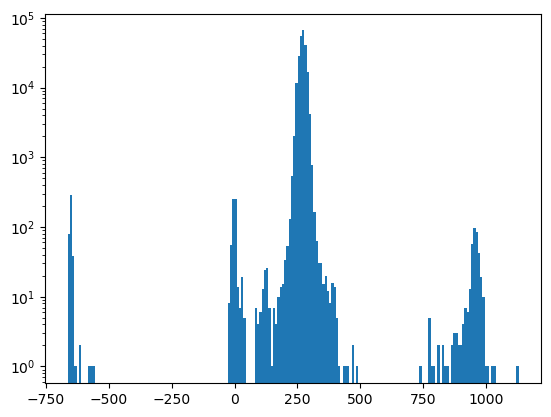

In [12]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [13]:
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100)  & (line_rad["sigma"] < 1.5) 
line_mask = line_rad[mask]

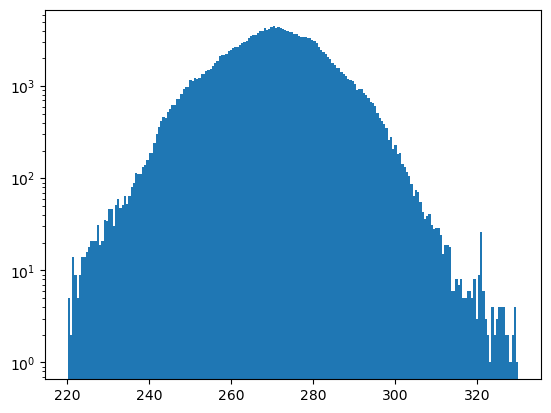

In [14]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

Plot flux and radial velocity

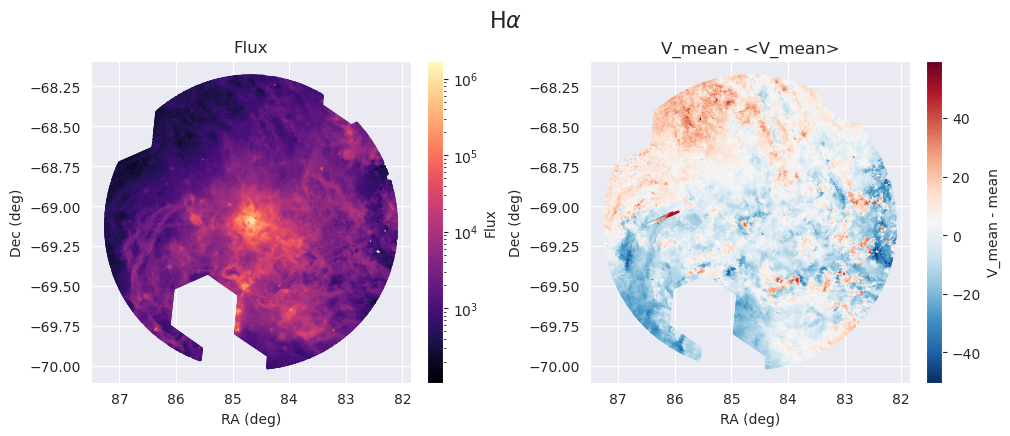

In [15]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

Plot flux and radial velocity in WCS

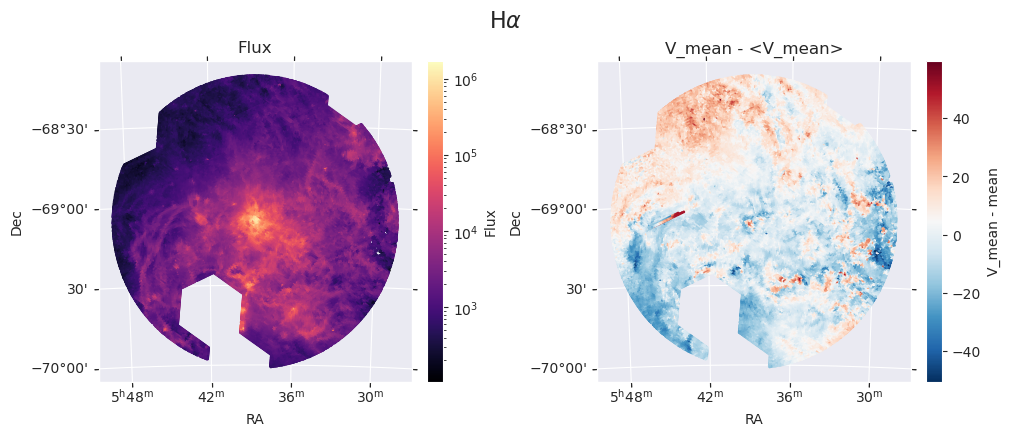

In [16]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_mean - <V_mean>"),
                                          figure_title=plot_label_line)
plt.show()

#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

# Rotation substraction

In [17]:
import lmc_model

In [18]:
df =  line_mask
c = SkyCoord(ra=df["RAdeg"].to_numpy() * u.deg, dec=df["DEdeg"].to_numpy() * u.deg)
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.65      , -69.33053993), (84.67528433, -69.325388  ),
     (84.70055662, -69.32023239), ..., (85.91216393, -68.76577774),
     (85.88921811, -68.77182839), (85.86617408, -68.77787917)]>

In [19]:
vmod = lmc_model.vmodel_lmc(c)


In [20]:
df.insert(
    loc=5,
    column="v_mod",
    value=vmod.value,
)


In [21]:
col = df.pop('V_mean')
df.insert(4, 'v_', col)

In [22]:
df.insert(
    loc=2,
    column="V_mean",
    value= df.v_-df.v_mod,
)

In [23]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
count,222020.000000,222020.000000,222020.000000,2.220200e+05,222020.000000,222020.000000,222020.000000
mean,84.743434,-69.080949,0.165502,9.276494e+03,0.841440,270.401268,270.235766
std,1.275231,0.427281,11.138730,3.407694e+04,0.129093,12.448334,3.247174
min,82.101852,-70.012179,-52.172066,1.059342e+02,0.237300,220.023700,263.693627
25%,83.781267,-69.404202,-6.514036,1.006186e+03,0.752300,262.501525,267.669202
50%,84.708755,-69.094773,0.487416,2.636627e+03,0.811500,270.608900,270.289599
75%,85.798398,-68.761121,7.111555,6.775874e+03,0.893100,278.533000,272.806889
max,87.248872,-68.182110,62.430357,1.710726e+06,1.499700,329.997900,276.681591


In [24]:
line_mask = df

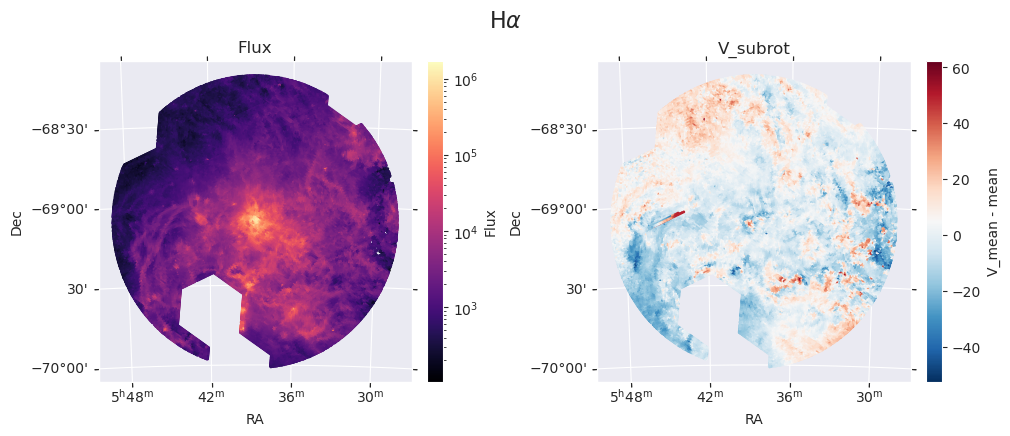

In [25]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_subrot"),
                                          figure_title=plot_label_line)
plt.show()

#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

# Creating and plotting subfields

Plotting subfields

Automatic

In [26]:
from circle_tools import make_circles_auto

Creatings subfields data

In [27]:
field_radius = 3305 * u.arcsec
radius = 1.5*413 * u.arcsec

In [28]:
circles = make_circles_auto(
    centro,
    radius,
    field_radius,
)

Plotting subfields

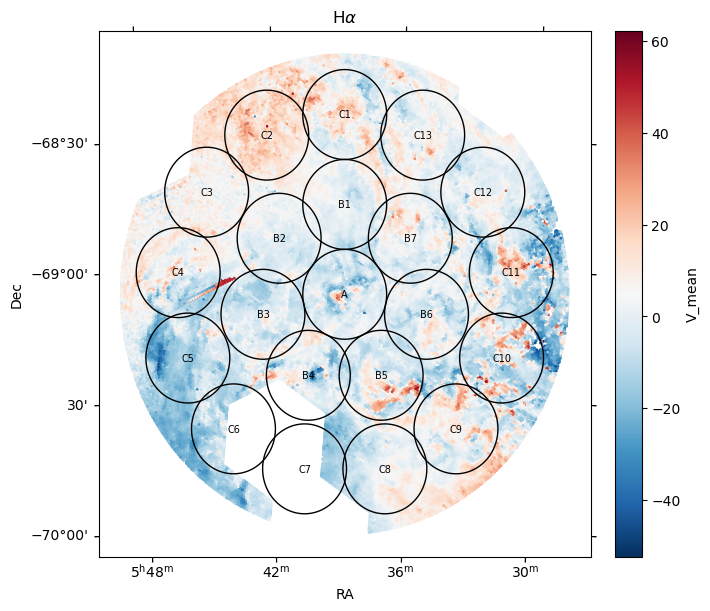

In [29]:
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes.patches import SphericalCircle

v1 = line_mask["V_mean"] - line_mask["V_mean"].mean()

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

sc = ax.scatter(
    line_mask["RAdeg"],
    line_mask["DEdeg"],
    s=1.0,
    c=v1,
    cmap="RdBu_r",
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title(plot_label_line)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("V_mean")

In [30]:
circles[4]

{'label': 'B4',
 'ring': 'B',
 'ring_index': 1,
 'angle_deg': 154.28571428571428,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (85.09960906, -69.40956618)>,
 'ra_deg': 85.09960905963752,
 'dec_deg': -69.4095661772462,
 'radius_arcsec': 619.5}

# Data for each circle

In [31]:
coords_all = SkyCoord(
    ra=line_mask["RAdeg"].values * u.deg,
    dec=line_mask["DEdeg"].values * u.deg,
    frame="icrs"
)

In [32]:
regions_data = {}

for circle in circles:
    radius_u = circle["radius_arcsec"] * u.arcsec
    sep = coords_all.separation(circle["center"])
    
    df_circle = line_mask.loc[sep <= radius_u].copy()
    
    regions_data[circle["label"]] = df_circle

# Export subfields

In [33]:

for circle in circles:
    label = circle["label"]
    ring = circle["ring"]
    angle_deg = circle["angle_deg"]
    circle_center = circle["center"]
    circle_radius = circle["radius_arcsec"] * u.arcsec

    # mask data inside this circle
    sep = coords_all.separation(circle_center)
    df_circle = line_mask.loc[sep <= circle_radius].copy()

    # skip empty regions
    if df_circle.empty:
        print(f"Skipping {label}: no data points inside circle.")
        continue

    # compute region-specific parameters
    N = np.sqrt(
        (df_circle.RAdeg.max() - df_circle.RAdeg.min()) *
        (df_circle.DEdeg.max() - df_circle.DEdeg.min())
    ) * pc * 3600

    sig = df_circle["V_mean"].std()

    # define output name
    circle_name_file = f"{name_file}_{label}"
    circle_name_id = f"{name_id}_{label}"

    # table HDU
    t = Table.from_pandas(df_circle.reset_index(drop=True))
    table_hdu = fits.BinTableHDU(t, name=circle_name_file)

    # primary HDU
    primary = fits.PrimaryHDU()
    hdr = primary.header

    hdr["FILE"]      = (circle_name_file, "Fits file name")
    hdr["NAME_ID"]   = (circle_name_id, "pipeline identifier")
    hdr["REG"]       = (region, "Region catalog name")
    hdr["NAME_REG"]  = (name_reg, "Region name")
    hdr["REG_ID"]    = (reg_id, "Region identifier")
    hdr["TYPE_OBJ"]  = (type_obj, "Type object")
    hdr["DIST"]      = (dist, "Distance in parsecs")
    hdr["INSTR"]     = (inst, "Instrument")
    hdr["LINE"]      = (plot_label_line, "Emission line name")
    hdr["LINE_ID"]   = (element, "Emission line identifier")
    hdr["L_REST"]    = (rest_wavelength, "Emission line rest wavelength")
    hdr["SIG"]       = (sig, "Standard deviation vel map")
    hdr["SIG2"]      = (sig**2, "Vel variance map")
    hdr["S0"]        = (s0, "Atmospheric seeing")
    hdr["BOX_SIZE"]  = (N, "Observational box_size")
    hdr["PC"]        = (pc, "parsec conversion")
    hdr["PIX"]       = (pix, "Instrument pixel scale")
    hdr["BINSIZE"]   = (bins, "Spatial binning factor")

    # circle metadata
    hdr["CIRC_ID"]   = (label, "Circle identifier")
    hdr["CIRCRING"]  = (ring, "Circle ring")
    hdr["CIRC_RA"]   = (circle_center.ra.deg, "Circle center RA deg")
    hdr["CIRC_DEC"]  = (circle_center.dec.deg, "Circle center Dec deg")
    hdr["CIRC_RAD"]  = (circle_radius.to(u.arcsec).value, "Circle radius arcsec")
    hdr["AUTHOR"]    = ("J. Garcia-Vazquez", "File creator")

    if angle_deg is not None:
        hdr["CIRC_PA"] = (angle_deg, "Circle position angle deg")

    hdul = fits.HDUList([primary, table_hdu])
    hdul.writeto(f"fits_ready/{circle_name_file}.fits", overwrite=True)

    print(f"Saved: fits_ready/{circle_name_file}.fits  ({len(df_circle)} rows)")

Saved: fits_ready/LVM-30Dor-6563_A.fits  (11846 rows)
Saved: fits_ready/LVM-30Dor-6563_B1.fits  (9458 rows)
Saved: fits_ready/LVM-30Dor-6563_B2.fits  (10517 rows)
Saved: fits_ready/LVM-30Dor-6563_B3.fits  (10018 rows)
Saved: fits_ready/LVM-30Dor-6563_B4.fits  (7354 rows)
Saved: fits_ready/LVM-30Dor-6563_B5.fits  (9776 rows)
Saved: fits_ready/LVM-30Dor-6563_B6.fits  (9273 rows)
Saved: fits_ready/LVM-30Dor-6563_B7.fits  (8580 rows)
Saved: fits_ready/LVM-30Dor-6563_C1.fits  (8414 rows)
Saved: fits_ready/LVM-30Dor-6563_C2.fits  (9247 rows)
Saved: fits_ready/LVM-30Dor-6563_C3.fits  (8476 rows)
Saved: fits_ready/LVM-30Dor-6563_C4.fits  (9260 rows)
Saved: fits_ready/LVM-30Dor-6563_C5.fits  (9612 rows)
Saved: fits_ready/LVM-30Dor-6563_C6.fits  (4070 rows)
Saved: fits_ready/LVM-30Dor-6563_C7.fits  (1533 rows)
Saved: fits_ready/LVM-30Dor-6563_C8.fits  (9179 rows)
Saved: fits_ready/LVM-30Dor-6563_C9.fits  (9596 rows)
Saved: fits_ready/LVM-30Dor-6563_C10.fits  (8680 rows)
Saved: fits_ready/LVM-30D

In [34]:
import pandas as pd

circles_df = pd.DataFrame([
    {
        "label": c["label"],
        "ring": c["ring"],
        "angle_deg": c["angle_deg"],
        "ra_deg": c["ra_deg"],
        "dec_deg": c["dec_deg"],
        "radius_arcsec": c["radius_arcsec"],
    }
    for c in circles
])

circles_df.to_csv("fits_ready/circle_catalog.csv", index=False)

In [35]:
export_names = [f"{name_file}_{circle['label']}" for circle in circles]

with open("fits_ready/filelist_circles.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(export_names) + "\n")